# ĐỒ ÁN 3: ĐÁNH GIÁ TRÊN TẬP DỮ LIỆU MỚI (TWITTER)
**Mục tiêu:** Kiểm chứng xem thuật toán Spectral Clustering với cơ chế bảo mật LDP có giữ được tính bền vững trên mạng xã hội Twitter hay không. Mạng Twitter thưa hơn và có tính chất lan truyền khác với Facebook.

In [1]:
# ==========================================
# CÀI ĐẶT MÔI TRƯỜNG KAGGLE / GOOGLE COLAB
# ==========================================
import os

# Clone repo nếu chạy trên Kaggle
!git clone https://github.com/FIT-SE23/DataMining-Lab3.git

# Di chuyển về thư mục gốc
%cd /kaggle/working/DataMining-Lab3

import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Thêm đường dẫn hiện tại vào sys.path để Python tìm thấy thư mục 'src'
sys.path.append('.') 

# Import các hàm dùng chung từ thư mục src
from src.utils import load_and_preprocess_graph, apply_edge_flipping, get_label_array
from src.model import spectral_clustering
from src.metrics import symmetric_difference_distance, calculate_all_metrics

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

Cloning into 'DataMining-Lab3'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 48 (delta 17), reused 30 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (48/48), 447.79 KiB | 4.11 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/kaggle/working/DataMining-Lab3


## 1. Load Dữ liệu Twitter
*Lưu ý:* Hàm `load_and_preprocess_graph` của chúng ta đọc file `.edges` mặc định bằng `nx.read_edgelist` (nó tự động đọc dưới dạng đồ thị vô hướng - Undirected Graph), nên nó hoàn toàn tương thích với file dữ liệu của Twitter.

In [2]:
print("Đang tải dữ liệu Twitter...")
# Chú ý: Đảm bảo bạn đã đổi tên 2 file twitter thành twitter_small.edges và twitter_medium.edges trong thư mục data/
G_small = load_and_preprocess_graph('./data/twitter_small.edges')
G_medium = load_and_preprocess_graph('./data/twitter_medium.edges')

print(f"Twitter Small: {G_small.number_of_nodes()} nodes")
print(f"Twitter Medium: {G_medium.number_of_nodes()} nodes")

# Lấy nhãn chuẩn (Baseline) từ đồ thị sạch
c1_s_true, c2_s_true, _ = spectral_clustering(G_small)
c1_m_true, c2_m_true, _ = spectral_clustering(G_medium)

all_nodes_s = list(G_small.nodes())
all_nodes_m = list(G_medium.nodes())

y_true_s = get_label_array(all_nodes_s, c1_s_true, c2_s_true)
y_true_m = get_label_array(all_nodes_m, c1_m_true, c2_m_true)

Đang tải dữ liệu Twitter...
Twitter Small: 93 nodes
Twitter Medium: 150 nodes


## 2. Chạy Thực Nghiệm Thêm Nhiễu (LDP Edge Flipping)

In [3]:
probabilities = [i * 0.005 for i in range(1, 40)] # p từ 0.005 đến 0.2
num_trials = 100 

results = {
    'small': {'d_size': [], 'acc': [], 'nmi': []},
    'medium': {'d_size': [], 'acc': [], 'nmi': []}
}

print("Đang chạy thực nghiệm thêm nhiễu...")
for p in tqdm(probabilities):
    tmp_s = {'d_size': [], 'acc': [], 'nmi': []}
    tmp_m = {'d_size': [], 'acc': [], 'nmi': []}
    
    for trial in range(num_trials):
        # --- Chạy cho Đồ thị Nhỏ ---
        G_s_noisy = apply_edge_flipping(G_small, p=p, seed=GLOBAL_SEED + trial)
        c1_s, c2_s, _ = spectral_clustering(G_s_noisy)
        y_pred_s = get_label_array(all_nodes_s, c1_s, c2_s)
        metrics_s = calculate_all_metrics(y_true_s, y_pred_s)
        
        tmp_s['d_size'].append(symmetric_difference_distance(c1_s_true, c2_s_true, c1_s, c2_s))
        tmp_s['acc'].append(metrics_s['ACC'])
        tmp_s['nmi'].append(metrics_s['NMI'])
        
        # --- Chạy cho Đồ thị Vừa ---
        G_m_noisy = apply_edge_flipping(G_medium, p=p, seed=GLOBAL_SEED + trial)
        c1_m, c2_m, _ = spectral_clustering(G_m_noisy)
        y_pred_m = get_label_array(all_nodes_m, c1_m, c2_m)
        metrics_m = calculate_all_metrics(y_true_m, y_pred_m)
        
        tmp_m['d_size'].append(symmetric_difference_distance(c1_m_true, c2_m_true, c1_m, c2_m))
        tmp_m['acc'].append(metrics_m['ACC'])
        tmp_m['nmi'].append(metrics_m['NMI'])
        
    # Lưu Worst-case cho d_size, Average cho ACC, NMI
    for metric in ['acc', 'nmi']:
        results['small'][metric].append(np.mean(tmp_s[metric]))
        results['medium'][metric].append(np.mean(tmp_m[metric]))
    
    results['small']['d_size'].append(np.max(tmp_s['d_size']))
    results['medium']['d_size'].append(np.max(tmp_m['d_size']))

Đang chạy thực nghiệm thêm nhiễu...


100%|██████████| 39/39 [18:59<00:00, 29.22s/it]


## 3. Vẽ biểu đồ và Đánh giá

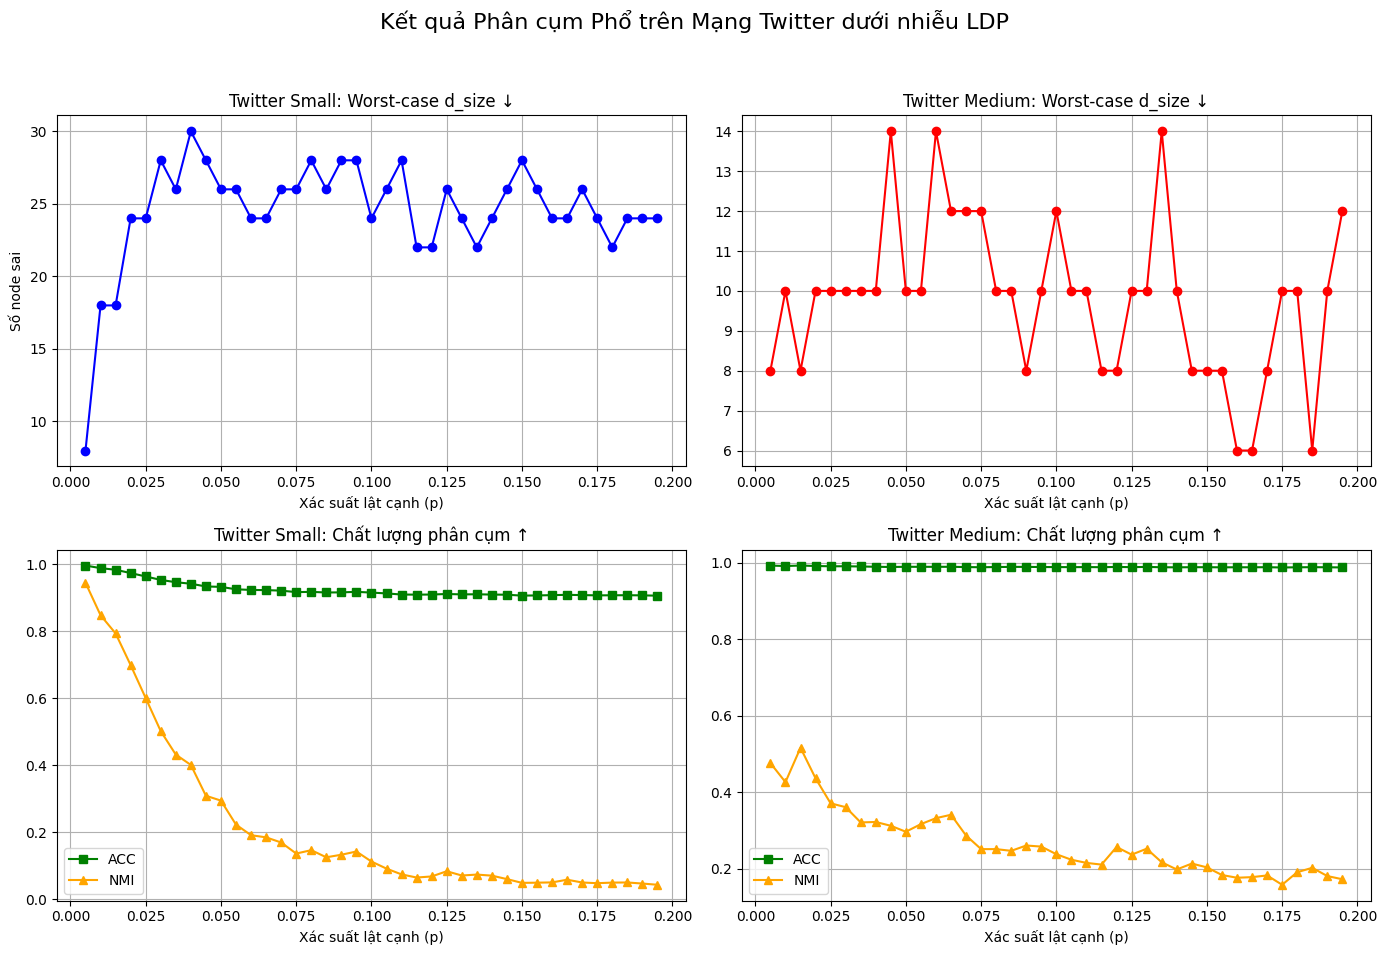

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Kết quả Phân cụm Phổ trên Mạng Twitter dưới nhiễu LDP', fontsize=16)

# Plot 1: Twitter Small d_size
axs[0, 0].plot(probabilities, results['small']['d_size'], 'o-', color='blue')
axs[0, 0].set_title('Twitter Small: Worst-case d_size ↓')
axs[0, 0].set_xlabel('Xác suất lật cạnh (p)')
axs[0, 0].set_ylabel('Số node sai')
axs[0, 0].grid(True)

# Plot 2: Twitter Medium d_size
axs[0, 1].plot(probabilities, results['medium']['d_size'], 'o-', color='red')
axs[0, 1].set_title('Twitter Medium: Worst-case d_size ↓')
axs[0, 1].set_xlabel('Xác suất lật cạnh (p)')
axs[0, 1].grid(True)

# Plot 3: Twitter Small Metrics
axs[1, 0].plot(probabilities, results['small']['acc'], 's-', label='ACC', color='green')
axs[1, 0].plot(probabilities, results['small']['nmi'], '^-', label='NMI', color='orange')
axs[1, 0].set_title('Twitter Small: Chất lượng phân cụm ↑')
axs[1, 0].set_xlabel('Xác suất lật cạnh (p)')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Plot 4: Twitter Medium Metrics
axs[1, 1].plot(probabilities, results['medium']['acc'], 's-', label='ACC', color='green')
axs[1, 1].plot(probabilities, results['medium']['nmi'], '^-', label='NMI', color='orange')
axs[1, 1].set_title('Twitter Medium: Chất lượng phân cụm ↑')
axs[1, 1].set_xlabel('Xác suất lật cạnh (p)')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()